# Fashion-MNIST Classification using Neural Network

In this notebook, we'll build a neural network to classify Fashion-MNIST images

In [1]:
!pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable
  Using cached torch-2.11.0-cp312-cp312-win_amd64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached torchaudio-2.11.0-cp312-cp312-win_amd64.whl.metadata (6.9 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.5/114.6 MB 837.5 kB/s eta 0:02:17
   ---------------------------------------- 0.8/114.6 MB 907.1 kB/s eta 0:02:06
   ---------------------------------------- 0.8/114.6 MB 907.1 kB/s eta 0:02:06
   ---------------------------------------- 1.3/114.6 MB 1.1 MB/s eta 0:01:42
    --------------------------------------- 1.6/114.6 MB 1.1 MB/s eta 0:01:40
    --------------------------------------- 1.8/114.6 MB 1.2 MB/s eta 0:01:36
    --------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from collections import OrderedDict

# Download training and testing data
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])
train_ds = datasets.FashionMNIST('F_MNIST_data', download=True, train=True, transform=transform)
test_ds = datasets.FashionMNIST('F_MNIST_data', download=True, train=False, transform=transform)

100%|██████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [02:00<00:00, 220kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 94.0kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:40<00:00, 109kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 5.17MB/s]


In [3]:
# split train set into training (80%) and validation set (20%)
train_num = len(train_ds)
indices = list(range(train_num))
np.random.shuffle(indices)
split = int(np.floor(0.2 * train_num))
val_idx, train_idx = indices[:split], indices[split:]
len(val_idx), len(train_idx)

(12000, 48000)

In [4]:
# prepare dataloaders
train_sampler = torch.utils.data.sampler.SubsetRandomSampler(train_idx)
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=64, sampler=train_sampler)
val_sampler = torch.utils.data.sampler.SubsetRandomSampler(val_idx)
val_dl = torch.utils.data.DataLoader(train_ds, batch_size=64, sampler=val_sampler)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=64, shuffle=True)

torch.Size([1, 28, 28]) torch.Size([64])
Sneaker


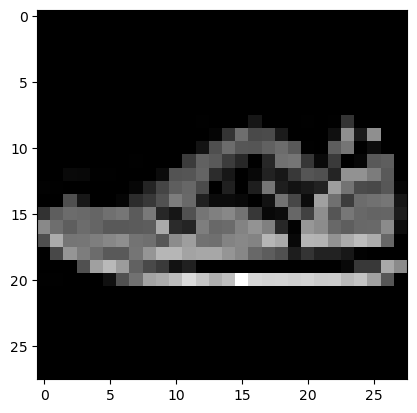

In [5]:
image, label = next(iter(train_dl))
print(image[0].shape, label.shape)
desc = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle Boot']
print(desc[label[0].item()])
plt.imshow(image[0].numpy().squeeze(), cmap='gray');

## Build the network

In [6]:
def network():
    model = nn.Sequential(OrderedDict([('fc1', nn.Linear(784, 128)),
                                       ('relu1', nn.ReLU()),
                                       ('drop1', nn.Dropout(0.25)),                                       
                                       ('fc2', nn.Linear(128, 64)),
                                       ('relu2', nn.ReLU()),
                                       ('drop1', nn.Dropout(0.25)),                                       
                                       ('output', nn.Linear(64, 10)),
                                       ('logsoftmax', nn.LogSoftmax(dim=1))]))
    # Use GPU if available
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)

    # define the criterion and optimizer
    loss_fn = nn.NLLLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.003)

    return model, loss_fn, optimizer, device                      

In [7]:
model, loss_fn, optimizer, device = network()
print(model)

Sequential(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=64, out_features=10, bias=True)
  (logsoftmax): LogSoftmax(dim=1)
)


## Train the network

In [8]:
def train_validate(model, loss_fn, optimizer, trainloader, testloader, device, n_epochs=25):
    train_losses = []
    test_losses = []
    for epoch in range(n_epochs):
        # Set mode to training - Dropouts will be used here
        model.train()
        train_epoch_loss = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            # flatten the images to batch_size x 784
            images = images.view(images.shape[0], -1)
            # forward pass
            outputs = model(images)
            # backpropogation
            train_batch_loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            train_batch_loss.backward()
            # Weight updates
            optimizer.step()
            train_epoch_loss += train_batch_loss.item()
        else:
            # One epoch of training complete
            # calculate average training epoch loss
            train_epoch_loss = train_epoch_loss/len(trainloader)

            # Now Validate on testset
            with torch.no_grad():
                test_epoch_acc = 0
                test_epoch_loss = 0
                # Set mode to eval - Dropouts will NOT be used here
                model.eval()
                for images, labels in testloader:
                    images, labels = images.to(device), labels.to(device)                    
                    # flatten images to batch_size x 784
                    images = images.view(images.shape[0], -1)
                    # make predictions 
                    test_outputs = model(images)
                    # calculate test loss
                    test_batch_loss = loss_fn(test_outputs, labels)
                    test_epoch_loss += test_batch_loss
                    
                    # get probabilities, extract the class associated with highest probability
                    proba = torch.exp(test_outputs)
                    _, pred_labels = proba.topk(1, dim=1)
                    
                    # compare actual labels and predicted labels
                    result = pred_labels == labels.view(pred_labels.shape)
                    batch_acc = torch.mean(result.type(torch.FloatTensor))
                    test_epoch_acc += batch_acc.item()
                else:
                    # One epoch of training and validation done
                    # calculate average testing epoch loss
                    test_epoch_loss = test_epoch_loss/len(testloader)
                    # calculate accuracy as correct_pred/total_samples
                    test_epoch_acc = test_epoch_acc/len(testloader)
                    # save epoch losses for plotting
                    train_losses.append(train_epoch_loss)
                    test_losses.append(test_epoch_loss)
                    # print stats for this epoch
                    print(f'Epoch: {epoch} -> train_loss: {train_epoch_loss:.19f}, val_loss: {test_epoch_loss:.19f}, ',
                          f'val_acc: {test_epoch_acc*100:.2f}%')
    # Finally plot losses
    plt.plot(train_losses, label='train-loss')
    plt.plot(test_losses, label='val-loss')
    plt.legend()
    plt.show()

Epoch: 0 -> train_loss: 0.5755607601404190143, val_loss: 0.4750571250915527344,  val_acc: 82.65%
Epoch: 1 -> train_loss: 0.4537536283731460340, val_loss: 0.3921847939491271973,  val_acc: 85.48%
Epoch: 2 -> train_loss: 0.4208294682304064560, val_loss: 0.3871099948883056641,  val_acc: 85.37%
Epoch: 3 -> train_loss: 0.4067392820119857810, val_loss: 0.3875463008880615234,  val_acc: 85.61%
Epoch: 4 -> train_loss: 0.3896028420726458386, val_loss: 0.3544245064258575439,  val_acc: 87.09%
Epoch: 5 -> train_loss: 0.3780229635238647190, val_loss: 0.3510918617248535156,  val_acc: 86.70%
Epoch: 6 -> train_loss: 0.3680656547149022684, val_loss: 0.3633928000926971436,  val_acc: 86.82%
Epoch: 7 -> train_loss: 0.3588258227507273301, val_loss: 0.3343376517295837402,  val_acc: 87.95%
Epoch: 8 -> train_loss: 0.3525744561652342512, val_loss: 0.3483282327651977539,  val_acc: 87.65%
Epoch: 9 -> train_loss: 0.3480716899832089761, val_loss: 0.3530689477920532227,  val_acc: 87.41%
Epoch: 10 -> train_loss: 0.344

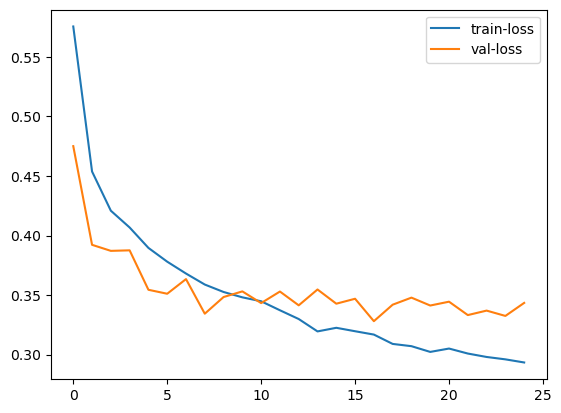

In [9]:
# Train and validate
train_validate(model, loss_fn, optimizer, train_dl, val_dl, device)

### Predict a single image

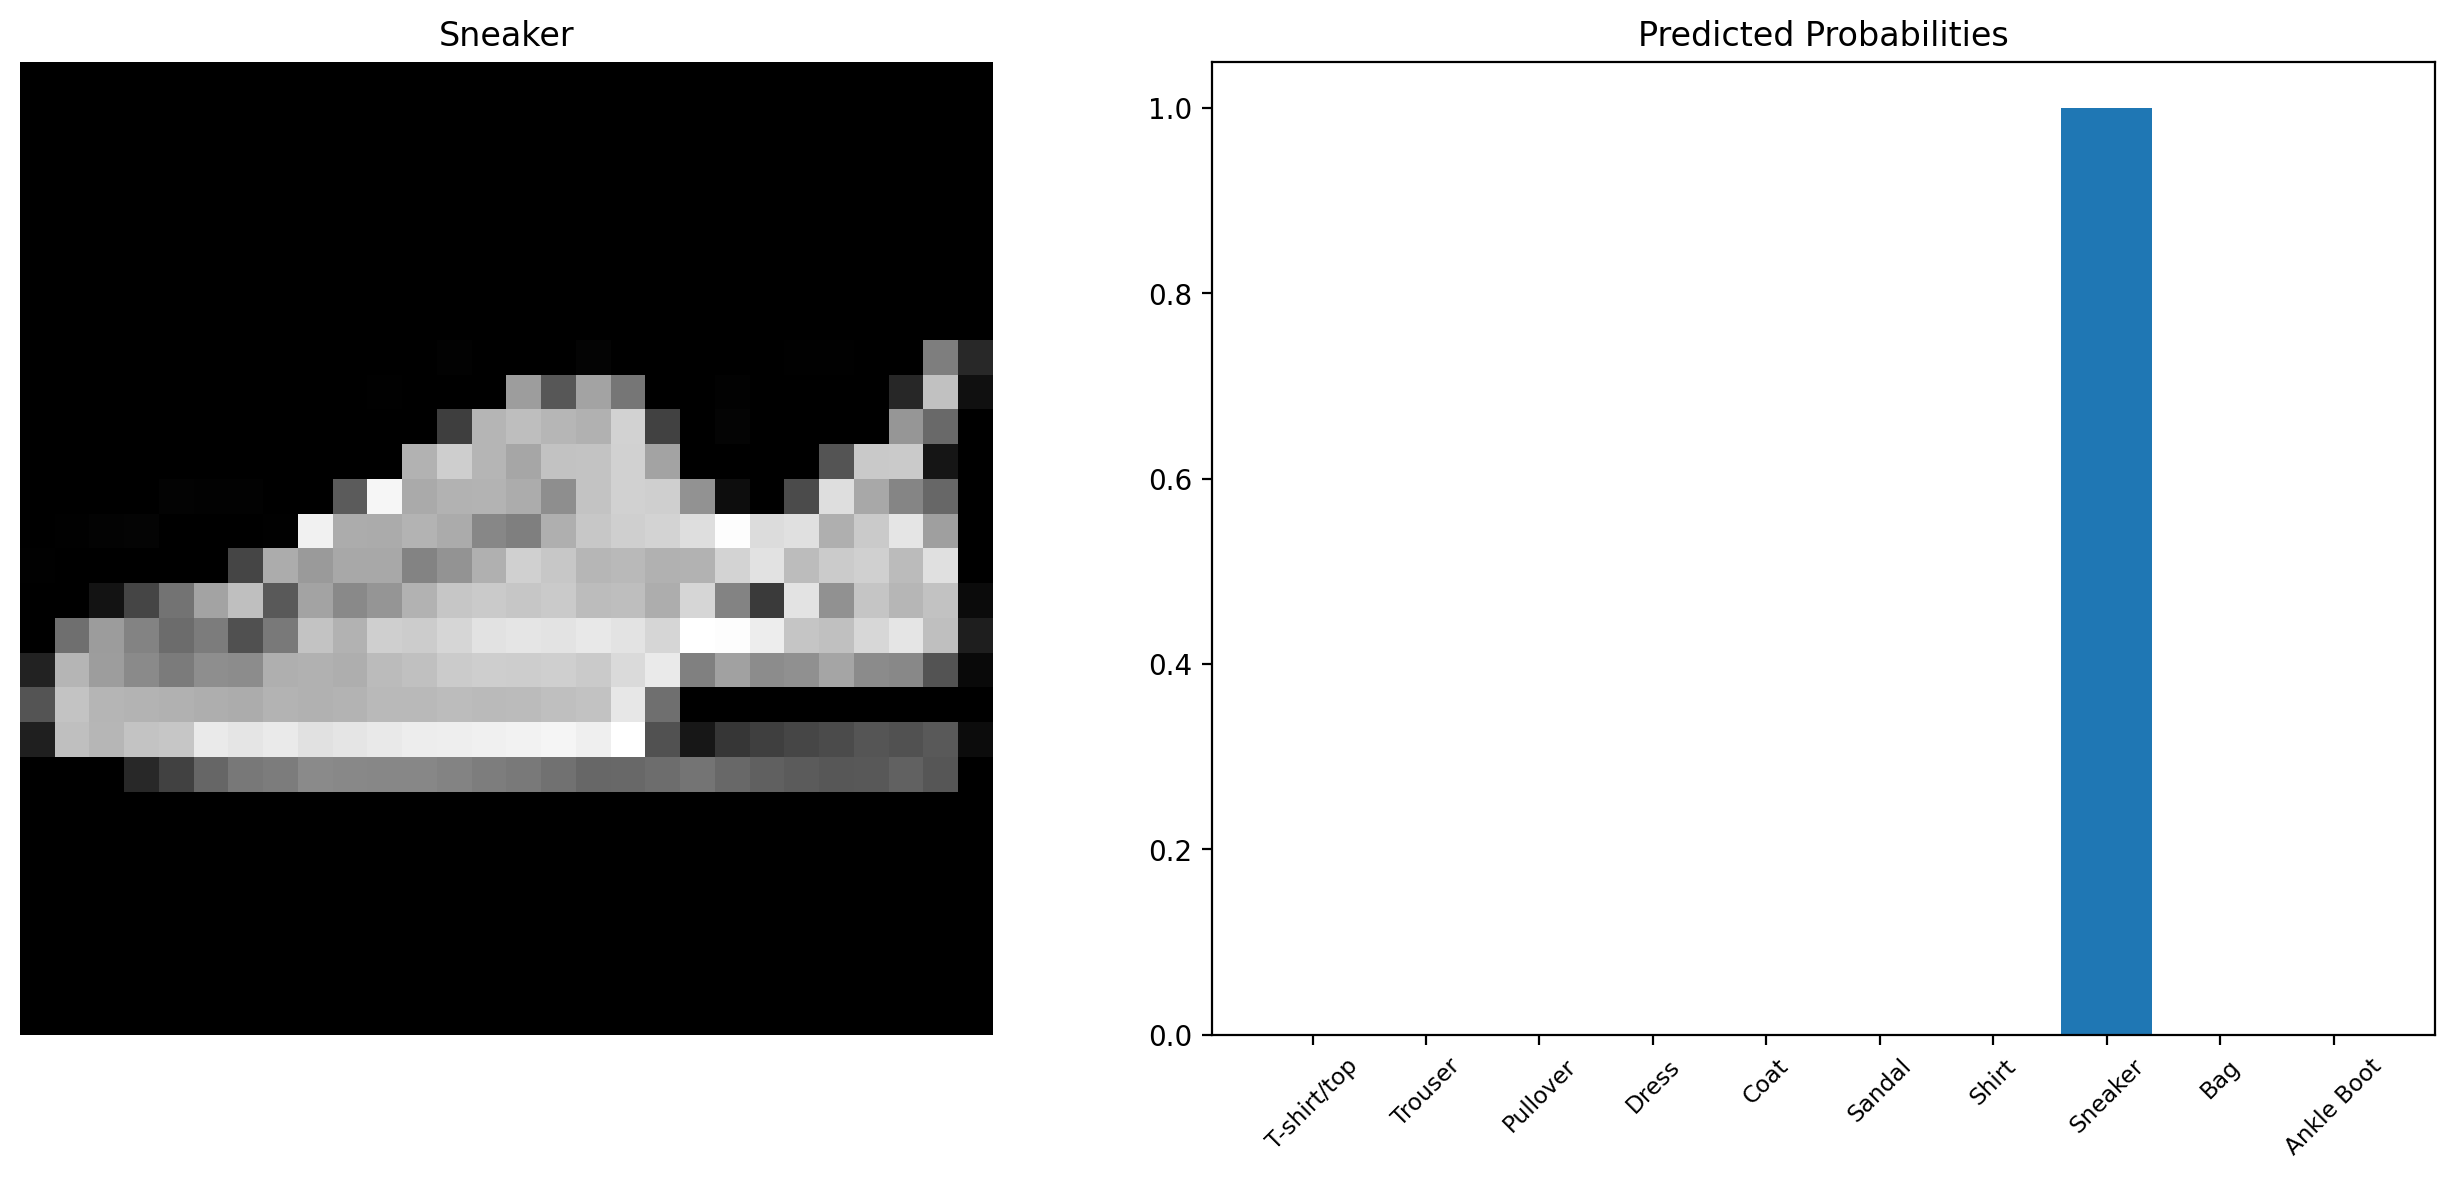

In [11]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Test out the network!
dataiter = iter(test_dl)

# FIX HERE
images, labels = next(dataiter)

images, labels = images.to(device), labels.to(device)

index = 49
img, label = images[index], labels[index]

# Convert 2D image to 1D vector
img = img.view(img.shape[0], -1)

# Calculate the class probabilities (softmax) for img
proba = torch.exp(model(img))

# Plot the image and probabilities
desc = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
        'Sandal','Shirt','Sneaker','Bag','Ankle Boot']

fig, (ax1, ax2) = plt.subplots(figsize=(13, 6), nrows=1, ncols=2)

ax1.axis('off')
ax1.imshow(images[index].cpu().numpy().squeeze(), cmap='gray')
ax1.set_title(desc[label.item()])

ax2.bar(range(10), proba.detach().cpu().numpy().squeeze())
ax2.set_xticks(range(10))
ax2.set_xticklabels(desc, rotation=45, size='small')
ax2.set_title('Predicted Probabilities')

plt.tight_layout()
plt.show()

## Validate on test set

In [12]:
# Validate
with torch.no_grad():
    batch_acc = []
    model.eval()
    for images, labels in test_dl:
        images, labels = images.to(device), labels.to(device)
        # flatten images to batch_size x 784
        images = images.view(images.shape[0], -1)
        # make predictions and get probabilities
        proba = torch.exp(model(images))
        # extract the class associted with highest probability
        _, pred_labels = proba.topk(1, dim=1)
        # compare actual labels and predicted labels
        result = pred_labels == labels.view(pred_labels.shape)
        acc = torch.mean(result.type(torch.FloatTensor))
        batch_acc.append(acc.item())
    else:
        print(f'Test Accuracy: {torch.mean(torch.tensor(batch_acc))*100:.2f}%')

Test Accuracy: 87.11%


## More powerful model

In [13]:
# Redefine network with dropout layers in between
def network():
    model = nn.Sequential(OrderedDict([('fc1', nn.Linear(784, 392)),
                                       ('relu1', nn.ReLU()),
                                       ('drop1', nn.Dropout(0.25)),
                                       ('fc12', nn.Linear(392, 196)),
                                       ('relu2', nn.ReLU()),
                                       ('drop2', nn.Dropout(0.25)),
                                       ('fc3', nn.Linear(196, 98)),
                                       ('relu3', nn.ReLU()),
                                       ('drop3', nn.Dropout(0.25)),                                       
                                       ('fc4', nn.Linear(98, 49)),
                                       ('relu4', nn.ReLU()),
                                       ('output', nn.Linear(49, 10)),
                                       ('logsoftmax', nn.LogSoftmax(dim=1))]))
    
    # Use GPU if available
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)

    # define the criterion and optimizer
    loss_fn = nn.NLLLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0007)

    return model, loss_fn, optimizer, device       

In [14]:
model, loss_fn, optimizer, device = network()
model

Sequential(
  (fc1): Linear(in_features=784, out_features=392, bias=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.25, inplace=False)
  (fc12): Linear(in_features=392, out_features=196, bias=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.25, inplace=False)
  (fc3): Linear(in_features=196, out_features=98, bias=True)
  (relu3): ReLU()
  (drop3): Dropout(p=0.25, inplace=False)
  (fc4): Linear(in_features=98, out_features=49, bias=True)
  (relu4): ReLU()
  (output): Linear(in_features=49, out_features=10, bias=True)
  (logsoftmax): LogSoftmax(dim=1)
)

In [ ]:
# Train and validate again with new architecture
train_validate(model, loss_fn, optimizer, train_dl, val_dl, device, n_epochs=35)

Epoch: 0 -> train_loss: 0.6672945130467414776, val_loss: 0.4719303250312805176,  val_acc: 83.10%
Epoch: 1 -> train_loss: 0.4585185975829760285, val_loss: 0.4185309410095214844,  val_acc: 84.72%
Epoch: 2 -> train_loss: 0.4153337291876474935, val_loss: 0.3720926046371459961,  val_acc: 86.31%
Epoch: 3 -> train_loss: 0.3897622382839520672, val_loss: 0.3702210783958435059,  val_acc: 86.64%
Epoch: 4 -> train_loss: 0.3670891531705856581, val_loss: 0.3790726363658905029,  val_acc: 86.05%
Epoch: 5 -> train_loss: 0.3513719332416852525, val_loss: 0.3293638229370117188,  val_acc: 87.83%
Epoch: 6 -> train_loss: 0.3401371417244275497, val_loss: 0.3261860609054565430,  val_acc: 88.15%
Epoch: 7 -> train_loss: 0.3260295709073543491, val_loss: 0.3429837822914123535,  val_acc: 87.24%
Epoch: 8 -> train_loss: 0.3161112769544124346, val_loss: 0.3219544887542724609,  val_acc: 88.16%
Epoch: 9 -> train_loss: 0.3085998614629109627, val_loss: 0.3166047632694244385,  val_acc: 88.49%
Epoch: 10 -> train_loss: 0.302

## Validate on test set

In [ ]:
# Validate
with torch.no_grad():
    model.eval()
    batch_acc = []
    for images, labels in test_dl:
        images, labels = images.to(device), labels.to(device)
        # flatten images to batch_size x 784
        images = images.view(images.shape[0], -1)
        # make predictions and get probabilities
        proba = torch.exp(model(images))
        # extract the class associted with highest probability
        _, pred_labels = proba.topk(1, dim=1)
        # compare actual labels and predicted labels
        result = pred_labels == labels.view(pred_labels.shape)
        acc = torch.mean(result.type(torch.FloatTensor))
        batch_acc.append(acc.item())
    else:
        print(f'Accuracy: {torch.mean(torch.tensor(batch_acc))*100:.2f}%')